# 🛠️ TEMPLATE HUẤN LUYỆN MÔ HÌNH (Dành cho Team 5 người)

**Quy định chung của nhóm (Trưởng nhóm yêu cầu):**
1. Tất cả thành viên phải copy file template này thành file riêng của mình (VD: `05A_Logistic.ipynb`, `05B_RandomForest.ipynb`...).
2. **KHÔNG** được thay đổi phần 1 (Load Data) và phần 2 (Chia Train/Test) để đảm bảo mọi người cùng thi trên một bộ dữ liệu.
3. Tất cả phải sử dụng hàm `evaluate_model` ở phần 3 để in ra kết quả cuối cùng (F1, Recall, Precision).
4. Phần 4 là khu vực làm việc riêng của từng người.

## 1. Import Thư viện & Load Dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Upload file trực tiếp từ máy tính lên Colab
from google.colab import files
uploaded = files.upload()

# Load file Master (Sạch 100%)
# Nhớ chọn file: gym_churn_master_final.csv
df = pd.read_csv('gym_churn_master_final.csv')

# Xóa các cột định danh không có ý nghĩa dự báo
df_ml = df.drop(columns=['short_p_id', 'customer_postal'])

# Chuyển đổi các biến phân loại (Categorical) thành biến giả (Dummy/One-Hot)
# Các cột cần chuyển: gender, main_density_class
df_ml = pd.get_dummies(
    df_ml,
    columns=['gender', 'main_density_class'],
    drop_first=True
)

print(f"Kích thước dữ liệu sau khi chuẩn bị: {df_ml.shape}")

Saving gym_churn_master_final.csv to gym_churn_master_final.csv
Kích thước dữ liệu sau khi chuẩn bị: (6327, 22)


## 2. Chia Dữ Liệu (Train / Test Split)
🚨 **LƯU Ý:** Tuyệt đối không sửa `random_state=42` để đảm bảo kết quả đồng nhất cả nhóm.

In [2]:
# Tách biến mục tiêu (y) và biến đặc trưng (X)
# LƯU Ý: Loại bỏ 'recency' để tránh hiện tượng Data Leakage (Rò rỉ dữ liệu)
X = df_ml.drop(columns=['is_churn', 'recency'])
y = df_ml['is_churn']

# Chia tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Số lượng tập Train: {X_train.shape[0]} dòng")
print(f"Số lượng tập Test: {X_test.shape[0]} dòng")
print("\nTỷ lệ Churn trong tập Train:")
print(y_train.value_counts(normalize=True))

Số lượng tập Train: 5061 dòng
Số lượng tập Test: 1266 dòng

Tỷ lệ Churn trong tập Train:
is_churn
1    0.781466
0    0.218534
Name: proportion, dtype: float64


## 3. Hàm Đánh Giá Chung Cho Cả Nhóm
Hàm này dùng để in ra các chỉ số metric và vẽ Confusion Matrix một cách thống nhất.

In [3]:
def evaluate_model(model_name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f" KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: {model_name}")
    print(f"{'='*40}")
    print("\n1. Phân loại tổng quát (Classification Report):")
    print(classification_report(y_true, y_pred))

    print("2. Chỉ số quan trọng nhất (Macro F1-Score):")
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"-> {f1:.4f}")

    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Dự báo: Ở lại', 'Dự báo: Nghỉ'],
                yticklabels=['Thực tế: Ở lại', 'Thực tế: Nghỉ'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

## 4. Khu Vực Làm Việc Riêng (Ví dụ: Logistic Regression - Trưởng Nhóm)
*(Các thành viên khác sẽ viết code mô hình của mình từ phần này trở đi)*


 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Logistic Regression (Baseline)

1. Phân loại tổng quát (Classification Report):
              precision    recall  f1-score   support

           0       0.31      0.64      0.42       277
           1       0.86      0.60      0.71       989

    accuracy                           0.61      1266
   macro avg       0.58      0.62      0.56      1266
weighted avg       0.74      0.61      0.64      1266

2. Chỉ số quan trọng nhất (Macro F1-Score):
-> 0.5615


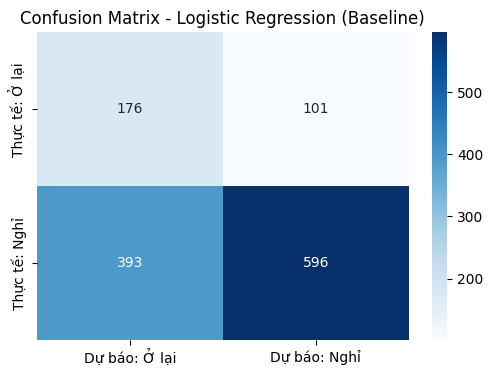

In [ ]:
from sklearn.linear_model import LogisticRegression

# 4.1 Chuẩn hóa dữ liệu (QUAN TRỌNG cho Logistic, SVM, MLP)
# Lưu ý: Fit trên Train, Transform trên cả Train và Test để tránh Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4.2 Khởi tạo và Huấn luyện mô hình Baseline
# Dùng class_weight='balanced' vì dữ liệu mất cân bằng (78% Churn)
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# 4.3 Dự báo trên tập Test
y_pred_lr = lr_model.predict(X_test_scaled)

# 4.4 Đánh giá bằng hàm chung của nhóm
evaluate_model("Logistic Regression (Baseline)", y_test, y_pred_lr)

### Phân tích thêm dành cho Trưởng Nhóm (Feature Importance của Logistic Regression)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31440\3947327918.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10), palette='coolwarm')


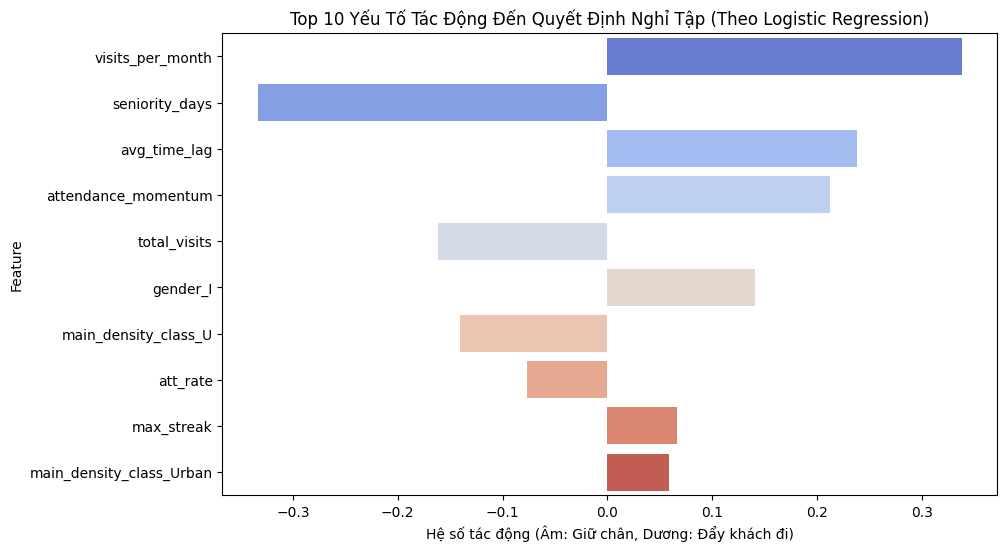

In [ ]:
# Lấy hệ số của mô hình Logistic để xem biến nào tác động mạnh nhất đến việc Churn
feature_names = X.columns
coefficients = lr_model.coef_[0]

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coef', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10), palette='coolwarm')
plt.title('Top 10 Yếu Tố Tác Động Đến Quyết Định Nghỉ Tập (Theo Logistic Regression)')
plt.xlabel('Hệ số tác động (Âm: Giữ chân, Dương: Đẩy khách đi)')
plt.show()

### 4.5 Tối ưu hóa siêu tham số bằng GridSearchCV (Nâng cao dành cho Trưởng Nhóm)

Đang tiến hành quét tham số tối ưu (Grid Search CV)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Tham số tốt nhất tìm được: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Điểm F1-Macro trung bình tốt nhất trên tập CV: 0.5474

 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Logistic Regression (GridSearchCV Optimized)

1. Phân loại tổng quát (Classification Report):
              precision    recall  f1-score   support

           0       0.30      0.64      0.41       277
           1       0.85      0.58      0.69       989

    accuracy                           0.60      1266
   macro avg       0.58      0.61      0.55      1266
weighted avg       0.73      0.60      0.63      1266

2. Chỉ số quan trọng nhất (Macro F1-Score):
-> 0.5519


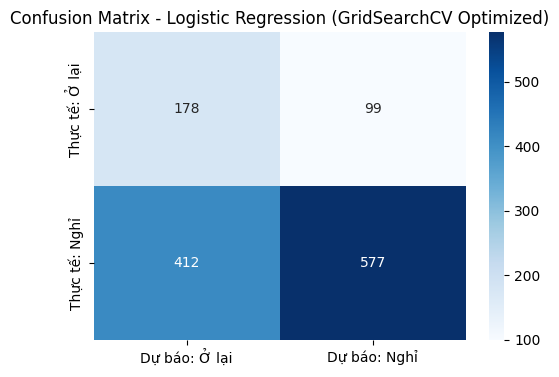

In [ ]:
from sklearn.model_selection import GridSearchCV

# Định nghĩa lưới tham số cần quét (Grid)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear hỗ trợ tốt cả l1 và l2 cho tập dữ liệu nhỏ
}

# Khởi tạo GridSearchCV với K-Fold CV = 5
# Sử dụng scoring='f1_macro' để tối ưu hóa đồng đều cho cả 2 nhóm (Active & Churn)
grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

print("Đang tiến hành quét tham số tối ưu (Grid Search CV)...")
grid_search.fit(X_train_scaled, y_train)

# In tham số tốt nhất
print("\nTham số tốt nhất tìm được:", grid_search.best_params_)
print(f"Điểm F1-Macro trung bình tốt nhất trên tập CV: {grid_search.best_score_:.4f}")

# Dự báo bằng mô hình đã tối ưu hóa tốt nhất
best_lr = grid_search.best_estimator_
y_pred_best = best_lr.predict(X_test_scaled)

# Đánh giá mô hình đã tối ưu
evaluate_model("Logistic Regression (GridSearchCV Optimized)", y_test, y_pred_best)

## 4.6 Khu Vực Làm Việc Riêng (Ví dụ: MLP / Artificial Neural Network)

Đang huấn luyện mô hình MLP...
Huấn luyện MLP hoàn tất.

 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: MLP / Artificial Neural Network

1. Phân loại tổng quát (Classification Report):
              precision    recall  f1-score   support

           0       1.00      0.73      0.84       277
           1       0.93      1.00      0.96       989

    accuracy                           0.94      1266
   macro avg       0.96      0.86      0.90      1266
weighted avg       0.94      0.94      0.94      1266

2. Chỉ số quan trọng nhất (Macro F1-Score):
-> 0.9023


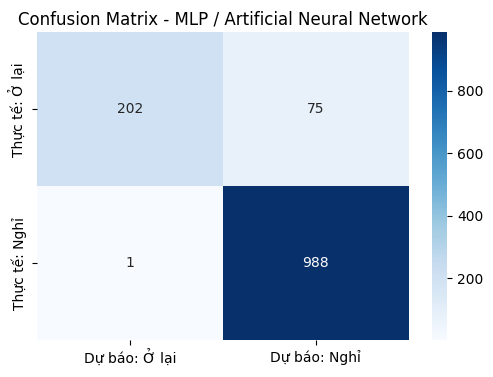

In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# 4.6.1 Chuẩn hóa dữ liệu (QUAN TRỌNG cho MLP)
# Dữ liệu đã được chuẩn hóa ở phần Logistic Regression, nhưng để đảm bảo tính độc lập,
# chúng ta sẽ thực hiện lại việc chuẩn hóa tại đây.
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_train)
X_test_scaled = scaler_mlp.transform(X_test)

# 4.6.2 Khởi tạo và Huấn luyện mô hình MLP
# Dùng class_weight='balanced' không trực tiếp có trong MLPClassifier.
# Có thể điều chỉnh qua 'solver' hoặc 'loss' và 'alpha' (L2 penalty) để giảm thiểu mất cân bằng.
# Để xử lý mất cân bằng, có thể dùng 'sampler' hoặc điều chỉnh trọng số thủ công.
# Tạm thời, chúng ta sẽ bắt đầu với cài đặt mặc định và có thể tối ưu sau.

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50), # 2 lớp ẩn với 100 và 50 nơ-ron
    max_iter=500, # Số lần lặp tối đa
    activation='relu', # Hàm kích hoạt ReLU
    solver='adam', # Thuật toán tối ưu Adam
    random_state=42,
    early_stopping=True, # Dừng sớm nếu điểm validation không cải thiện
    validation_fraction=0.1, # 10% dữ liệu train làm validation
    n_iter_no_change=10 # Dừng nếu không cải thiện trong 10 epoch
)

print("Đang huấn luyện mô hình MLP...")
mlp_model.fit(X_train_scaled, y_train)
print("Huấn luyện MLP hoàn tất.")

# 4.6.3 Dự báo trên tập Test
y_pred_mlp = mlp_model.predict(X_test_scaled)

# 4.6.4 Đánh giá bằng hàm chung của nhóm
evaluate_model("MLP / Artificial Neural Network", y_test, y_pred_mlp)


### Phân tích thêm dành cho Trưởng Nhóm (Feature Importance của MLP / Artificial Neural Network)

Mô hình MLP (Mạng nơ-ron nhân tạo) là một mô hình 'hộp đen', không có các hệ số (coefficients) trực tiếp như Logistic Regression để chúng ta có thể dễ dàng hiểu được tầm quan trọng của từng đặc trưng. Để đánh giá mức độ quan trọng của các đặc trưng đối với mô hình MLP, chúng ta có thể sử dụng các phương pháp giải thích mô hình như **Permutation Importance**.

Đang tính toán Permutation Importance cho mô hình MLP...
Permutation Importance hoàn tất.

Top 10 Đặc trưng quan trọng nhất đối với MLP:


,Feature,Importance_Mean,Importance_Std
0,attendance_momentum,0.224092,0.009192
1,seniority_days,0.009953,0.002267
2,total_visits,0.007109,0.002643
3,visits_per_month,0.003791,0.001687
4,main_density_class_Exurban,0.001343,0.000794
5,main_density_class_Urban,0.000869,0.001195
6,main_density_class_Light Urban,0.000790,0.000865
7,att_rate,0.000711,0.001027
8,weekend_ratio,0.000632,0.001048
9,main_density_class_2nd Tier Suburban,0.000395,0.000809


/tmp/ipykernel_5154/1065550277.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


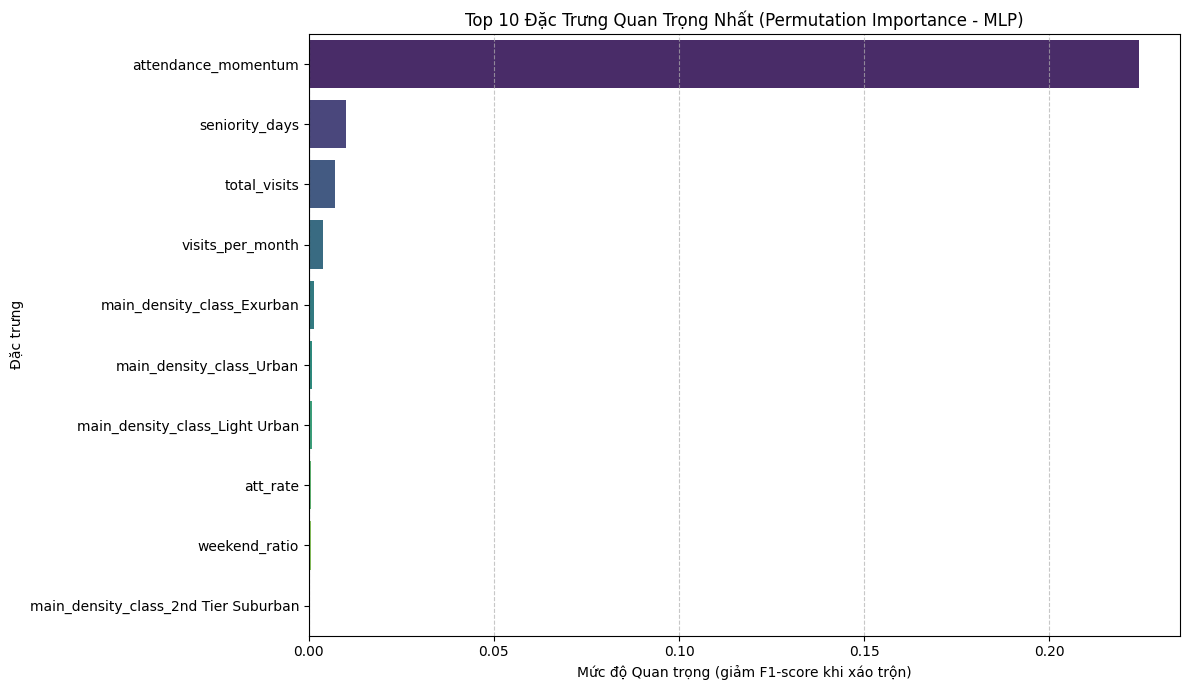

In [6]:
from sklearn.inspection import permutation_importance

print("Đang tính toán Permutation Importance cho mô hình MLP...")

# Tính toán Permutation Importance trên tập kiểm tra
result = permutation_importance(
    mlp_model, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Sắp xếp các đặc trưng theo mức độ quan trọng giảm dần
sorted_idx = result.importances_mean.argsort()[::-1]

# Tạo DataFrame để dễ dàng hiển thị và trực quan hóa
permutation_importance_df = pd.DataFrame({
    'Feature': X.columns[sorted_idx],
    'Importance_Mean': result.importances_mean[sorted_idx],
    'Importance_Std': result.importances_std[sorted_idx]
})

print("Permutation Importance hoàn tất.")

# Hiển thị 10 đặc trưng quan trọng nhất
print("\nTop 10 Đặc trưng quan trọng nhất đối với MLP:")
display(permutation_importance_df.head(10))

# Trực quan hóa Top 10 đặc trưng quan trọng nhất
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Importance_Mean',
    y='Feature',
    data=permutation_importance_df.head(10),
    palette='viridis'
)
plt.title('Top 10 Đặc Trưng Quan Trọng Nhất (Permutation Importance - MLP)')
plt.xlabel('Mức độ Quan trọng (giảm F1-score khi xáo trộn)')
plt.ylabel('Đặc trưng')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 4.7 Tối ưu hóa siêu tham số bằng GridSearchCV (Nâng cao dành cho Trưởng Nhóm - MLP)

Đang tiến hành quét tham số tối ưu (Grid Search CV) cho MLP...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Tham số tốt nhất tìm được cho MLP: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01, 'solver': 'adam'}
Điểm F1-Macro trung bình tốt nhất trên tập CV cho MLP: 0.9149

 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: MLP / Artificial Neural Network (GridSearchCV Optimized)

1. Phân loại tổng quát (Classification Report):
              precision    recall  f1-score   support

           0       0.96      0.78      0.86       277
           1       0.94      0.99      0.97       989

    accuracy                           0.94      1266
   macro avg       0.95      0.89      0.91      1266
weighted avg       0.95      0.94      0.94      1266

2. Chỉ số quan trọng nhất (Macro F1-Score):
-> 0.9133


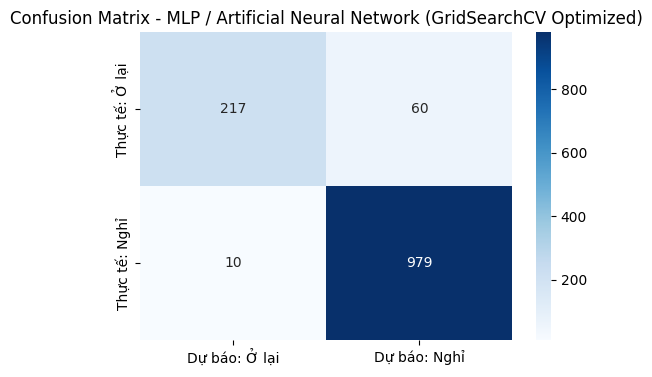

In [7]:
from sklearn.model_selection import GridSearchCV

# Định nghĩa lưới tham số cần quét (Grid) cho MLPClassifier
param_grid_mlp = {
    'hidden_layer_sizes': [(100,), (50, 25), (100, 50, 25)], # Các cấu trúc lớp ẩn khác nhau
    'activation': ['relu', 'tanh'], # Các hàm kích hoạt
    'solver': ['adam'], # Adam thường hoạt động tốt
    'alpha': [0.0001, 0.001, 0.01], # Hệ số điều chuẩn L2 (để tránh overfitting)
    'learning_rate_init': [0.001, 0.01] # Tốc độ học ban đầu
}

# Khởi tạo GridSearchCV với K-Fold CV = 5
# Sử dụng scoring='f1_macro' để tối ưu hóa đồng đều cho cả 2 nhóm (Active & Churn)
grid_search_mlp = GridSearchCV(
    estimator=MLPClassifier(max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.1, n_iter_no_change=10),
    param_grid=param_grid_mlp,
    cv=5,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1 # Sử dụng tất cả các nhân CPU có sẵn
)

print("Đang tiến hành quét tham số tối ưu (Grid Search CV) cho MLP...")
grid_search_mlp.fit(X_train_scaled, y_train)

# In tham số tốt nhất
print("\nTham số tốt nhất tìm được cho MLP:", grid_search_mlp.best_params_)
print(f"Điểm F1-Macro trung bình tốt nhất trên tập CV cho MLP: {grid_search_mlp.best_score_:.4f}")

# Dự báo bằng mô hình MLP đã tối ưu hóa tốt nhất
best_mlp = grid_search_mlp.best_estimator_
y_pred_best_mlp = best_mlp.predict(X_test_scaled)

# Đánh giá mô hình MLP đã tối ưu
evaluate_model("MLP / Artificial Neural Network (GridSearchCV Optimized)", y_test, y_pred_best_mlp)
